In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "final_security.csv"
)

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (9230, 13)


,comment_id,comment,repo,language,pr_id,c_id,matched_strong,matched_weak,security_categories,candidate_score,indicator_strength,security_label,review_notes
0,208849771,Should not `ansible.utils.encrypt.random_passw...,ansible,Python,21225735,1095841089,NaN,password; encryption,authentication; cryptography,2,weak,0,"Keyword appears while describing, implementing..."
1,258431281,These routes are quite a lot to copy in here. ...,AspNetCore,NaN,56148722,1303642745,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
2,269690752,slow-tests does also contain ssl-certificate r...,chainweb-node,Haskell,58703769,1341744273,NaN,ssl; certificate,cryptography,2,weak,0,"Keyword appears while describing, implementing..."
3,195074858,minikube start --bootstrapper localkube --extr...,service-manager,NaN,39143713,1005582331,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
4,224629987,There might be some confusion. I ran this cod...,hail,Scala,47236096,1161354134,NaN,secret; session,authentication; secrets,2,weak,1,Comment explicitly describes a security weakne...


In [3]:
df_binary = df[
    df["security_label"].isin([0, 1])
].copy()

df_binary["comment"] = (
    df_binary["comment"]
    .fillna("")
    .astype(str)
)

df_binary["label"] = (
    df_binary["security_label"]
    .astype(int)
)

df_binary["security_categories"] = (
    df_binary["security_categories"]
    .fillna("uncategorized")
    .astype(str)
)

df_binary = df_binary.reset_index(drop=True)

print("Binary dataset shape:", df_binary.shape)

print("\nLabel distribution:")
print(df_binary["label"].value_counts().sort_index())

Binary dataset shape: (9147, 14)

Label distribution:
label
0    6119
1    3028
Name: count, dtype: int64


In [4]:
X = df_binary["comment"]
y = df_binary["label"]

train_indices, test_indices = train_test_split(
    np.arange(len(df_binary)),
    test_size=0.20,
    random_state=42,
    stratify=y
)

train_indices = np.sort(train_indices)
test_indices = np.sort(test_indices)

train_df = df_binary.iloc[train_indices].copy()
test_df = df_binary.iloc[test_indices].copy()

X_train = train_df["comment"]
X_test = test_df["comment"]

y_train = train_df["label"]
y_test = test_df["label"]

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 7317
Testing rows: 1830


In [5]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Overall accuracy:", accuracy_score(y_test, y_pred))
print(
    "Overall balanced accuracy:",
    balanced_accuracy_score(y_test, y_pred)
)
print("Overall precision:", precision_score(y_test, y_pred))
print("Overall recall:", recall_score(y_test, y_pred))
print("Overall F1-score:", f1_score(y_test, y_pred))

Overall accuracy: 0.9759562841530055
Overall balanced accuracy: 0.9649461269656378
Overall precision: 0.9947183098591549
Overall recall: 0.9323432343234324
Overall F1-score: 0.9625212947189097


In [6]:
test_df["predicted_label"] = y_pred

test_df["correct_prediction"] = (
    test_df["label"] == test_df["predicted_label"]
)

display(
    test_df[
        [
            "comment_id",
            "comment",
            "security_categories",
            "label",
            "predicted_label",
            "correct_prediction"
        ]
    ].head()
)

,comment_id,comment,security_categories,label,predicted_label,correct_prediction
3,195074858,minikube start --bootstrapper localkube --extr...,authorization,0,0,True
5,205547594,XSS vulnerability ????,injection; vulnerability,1,1,True
7,279841992,Clients can opt-out of automatic key rotation ...,authorization,0,0,True
8,215627591,le token est dans le json ou dans l'url /users...,authentication; secrets,0,0,True
13,267623394,Expanding our existing token authentication is...,authentication; secrets,0,0,True


In [7]:
def split_categories(category_value):
    if pd.isna(category_value):
        return []

    categories = [
        category.strip()
        for category in str(category_value).split(";")
        if category.strip()
    ]

    return categories


test_df["category_list"] = (
    test_df["security_categories"]
    .apply(split_categories)
)

display(
    test_df[
        [
            "comment_id",
            "security_categories",
            "category_list"
        ]
    ].head(10)
)

,comment_id,security_categories,category_list
3,195074858,authorization,[authorization]
5,205547594,injection; vulnerability,"[injection, vulnerability]"
7,279841992,authorization,[authorization]
8,215627591,authentication; secrets,"[authentication, secrets]"
13,267623394,authentication; secrets,"[authentication, secrets]"
21,257762974,authorization,[authorization]
50,208977237,authentication; cryptography,"[authentication, cryptography]"
79,270213999,authorization,[authorization]
80,285197416,cryptography,[cryptography]
84,285057563,general_security; secrets; vulnerability,"[general_security, secrets, vulnerability]"


In [8]:
category_rows = []

all_categories = sorted(
    {
        category
        for categories in test_df["category_list"]
        for category in categories
    }
)

for category in all_categories:

    category_mask = test_df["category_list"].apply(
        lambda categories: category in categories
    )

    category_df = test_df[category_mask].copy()

    category_y_true = category_df["label"]
    category_y_pred = category_df["predicted_label"]

    category_accuracy = accuracy_score(
        category_y_true,
        category_y_pred
    )

    category_precision = precision_score(
        category_y_true,
        category_y_pred,
        zero_division=0
    )

    category_recall = recall_score(
        category_y_true,
        category_y_pred,
        zero_division=0
    )

    category_f1 = f1_score(
        category_y_true,
        category_y_pred,
        zero_division=0
    )

    false_positive_count = (
        (category_y_true == 0)
        & (category_y_pred == 1)
    ).sum()

    false_negative_count = (
        (category_y_true == 1)
        & (category_y_pred == 0)
    ).sum()

    category_rows.append({
        "category": category,
        "sample_count": len(category_df),
        "actual_negative": int((category_y_true == 0).sum()),
        "actual_positive": int((category_y_true == 1).sum()),
        "accuracy": category_accuracy,
        "precision": category_precision,
        "recall": category_recall,
        "f1_score": category_f1,
        "false_positives": int(false_positive_count),
        "false_negatives": int(false_negative_count)
    })

category_results = pd.DataFrame(category_rows)

category_results = category_results.sort_values(
    by="sample_count",
    ascending=False
).reset_index(drop=True)

display(
    category_results.style.format({
        "accuracy": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1_score": "{:.4f}"
    })
)

,category,sample_count,actual_negative,actual_positive,accuracy,precision,recall,f1_score,false_positives,false_negatives
0,authentication,585,544,41,0.9641,0.9167,0.5366,0.6769,2,19
1,secrets,560,509,51,0.9625,0.9688,0.6078,0.7470,1,20
2,authorization,438,415,23,0.9680,0.9091,0.4348,0.5882,1,13
3,cryptography,405,376,29,0.9630,1.0000,0.4828,0.6512,0,15
4,vulnerability,368,0,368,0.9946,1.0000,0.9946,0.9973,0,2
5,general_security,256,159,97,0.9688,0.9890,0.9278,0.9574,1,7
6,injection,142,0,142,1.0000,1.0000,1.0000,1.0000,0,0
7,input_validation,88,69,19,0.9545,1.0000,0.7895,0.8824,0,4
8,memory_safety,32,0,32,1.0000,1.0000,1.0000,1.0000,0,0
9,malicious_activity,11,0,11,1.0000,1.0000,1.0000,1.0000,0,0


In [9]:
category_results_path = (
    RESULTS_DIR
    / "category_level_error_analysis.csv"
)

category_results.to_csv(
    category_results_path,
    index=False
)

print("Saved category results to:")
print(category_results_path)

Saved category results to:
/Users/mustafaahmed/Documents/Security Code Review Analysis/results/category_level_error_analysis.csv


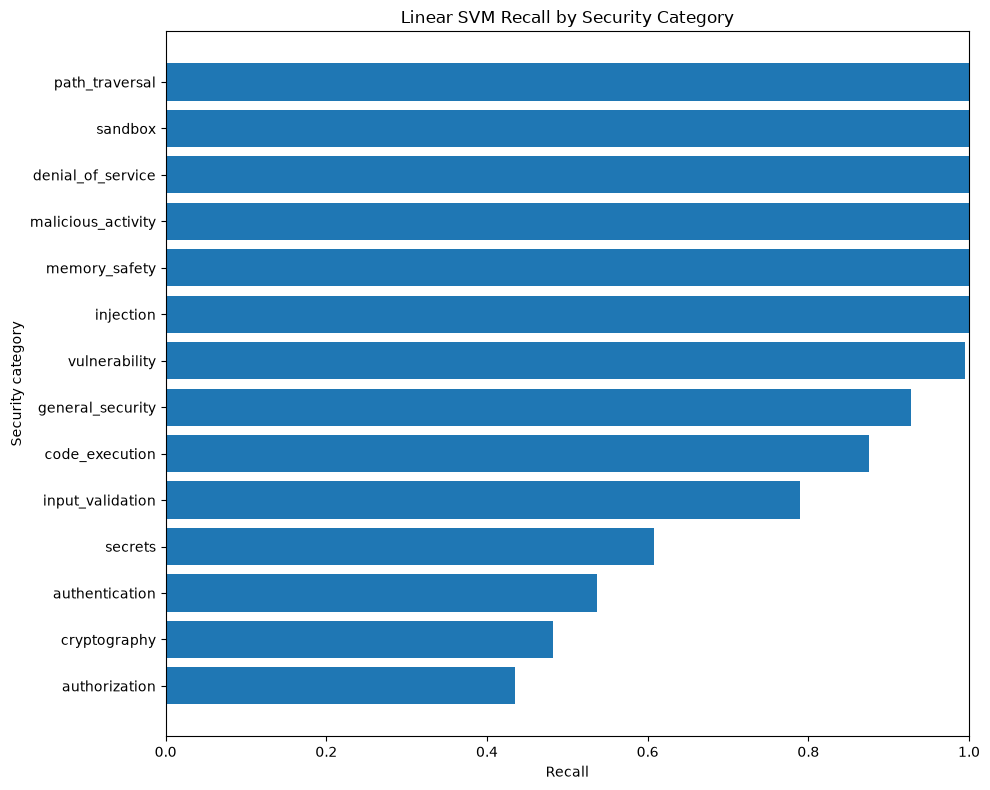

In [10]:
plot_df = category_results.sort_values(
    by="recall",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["category"],
    plot_df["recall"]
)

plt.title("Linear SVM Recall by Security Category")
plt.xlabel("Recall")
plt.ylabel("Security category")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

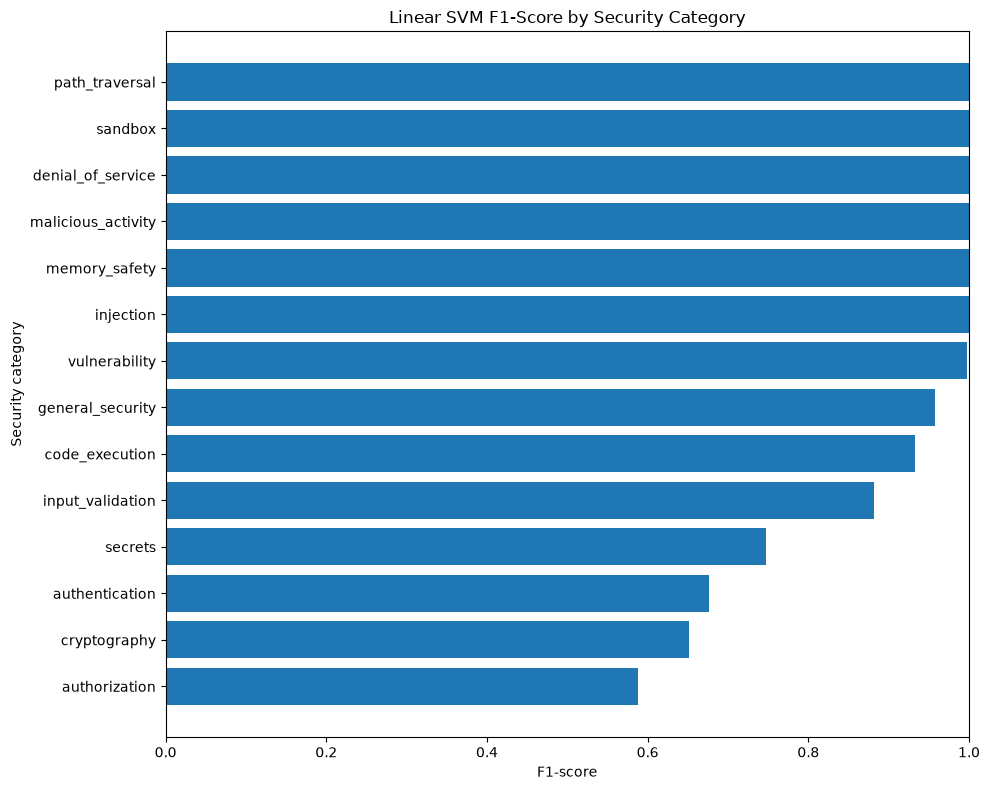

In [11]:
plot_df = category_results.sort_values(
    by="f1_score",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["category"],
    plot_df["f1_score"]
)

plt.title("Linear SVM F1-Score by Security Category")
plt.xlabel("F1-score")
plt.ylabel("Security category")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [12]:
most_false_negatives = category_results.sort_values(
    by="false_negatives",
    ascending=False
)

display(
    most_false_negatives[
        [
            "category",
            "sample_count",
            "actual_positive",
            "recall",
            "f1_score",
            "false_negatives"
        ]
    ].head(15)
)

,category,sample_count,actual_positive,recall,f1_score,false_negatives
1,secrets,560,51,0.607843,0.746988,20
0,authentication,585,41,0.536585,0.676923,19
3,cryptography,405,29,0.482759,0.651163,15
2,authorization,438,23,0.434783,0.588235,13
5,general_security,256,97,0.927835,0.957447,7
7,input_validation,88,19,0.789474,0.882353,4
4,vulnerability,368,368,0.994565,0.997275,2
10,code_execution,8,8,0.875000,0.933333,1
6,injection,142,142,1.000000,1.000000,0
8,memory_safety,32,32,1.000000,1.000000,0


In [13]:
false_negative_df = test_df[
    (test_df["label"] == 1)
    & (test_df["predicted_label"] == 0)
].copy()

print("Total false negatives:", len(false_negative_df))

display(
    false_negative_df[
        [
            "comment_id",
            "comment",
            "security_categories",
            "label",
            "predicted_label"
        ]
    ].head(50)
)

Total false negatives: 41


,comment_id,comment,security_categories,label,predicted_label
446,248428300,"Out of curiosity, this means that we're Authen...",authentication; secrets,1,0
531,242920176,Single-user is not a case at all. There is no ...,authentication; authorization,1,0
578,256440035,This is the client giving the server a valid a...,authentication; general_security; secrets,1,0
792,238653537,"This name is confusing to me, do you pretend t...",authentication,1,0
813,197577498,It's also possible that you'd raise a `KeyErro...,authorization,1,0
1022,228730173,I'm not a huge fan of stuffing this informatio...,authentication; authorization,1,0
1987,240574119,Can we recommend using ENV for the token pleas...,general_security; secrets,1,0
2721,258808854,"The error message make no sense. Also, `assert...",vulnerability,1,0
2799,269237008,I think we should add security note on using t...,general_security; input_validation,1,0
2945,257410055,Notebook has no control over the authorization...,authentication; authorization,1,0
